# 5. What Are the Most "Optimal" Movie Genres?

**Question:** Which genres combine high catalog demand (lots of titles) with high average runtime (a proxy for production investment)?

This directly mirrors the reference project's "optimal skills" scatter plot — swapping skill-demand-vs-salary for genre-volume-vs-runtime.

## Import & Clean Up Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')
df['genre_list'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genre_list').rename(columns={'genre_list': 'genre'})

df_movies_genres = df_genres[df_genres['type'] == 'Movie'].copy()
df_movies_genres['duration_min'] = df_movies_genres['duration'].str.extract(r'(\d+)').astype(float)

genre_summary = (
    df_movies_genres.groupby('genre')
    .agg(count=('show_id', 'count'), avg_duration=('duration_min', 'mean'))
    .reset_index()
)
genre_summary = genre_summary[genre_summary['count'] >= 30]
genre_summary.sort_values('count', ascending=False).head(10)

## Visualize Data

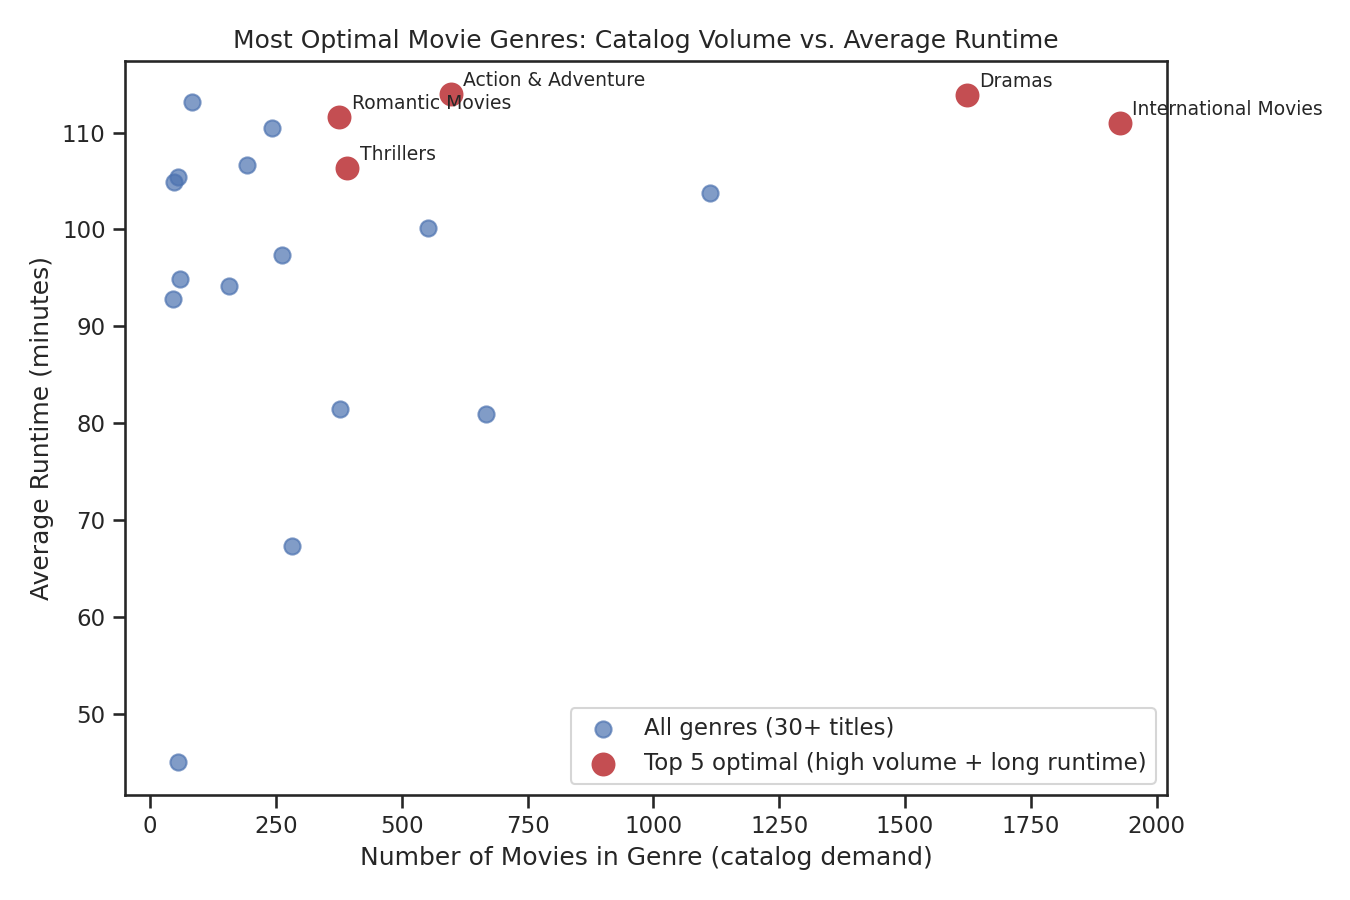

In [1]:
optimal = genre_summary[genre_summary['count'] >= 300].sort_values('avg_duration', ascending=False).head(5)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(genre_summary['count'], genre_summary['avg_duration'], color='#4C72B0', s=60, alpha=0.7,
           label='All genres (30+ titles)')
ax.scatter(optimal['count'], optimal['avg_duration'], color='#C44E52', s=110,
           label='Top 5 optimal (high volume + long runtime)')

for _, row in optimal.iterrows():
    ax.annotate(row['genre'], (row['count'], row['avg_duration']), textcoords='offset points',
                xytext=(6, 4), fontsize=9)

ax.set_xlabel('Number of Movies in Genre (catalog demand)')
ax.set_ylabel('Average Runtime (minutes)')
ax.set_title('Most Optimal Movie Genres: Catalog Volume vs. Average Runtime')
ax.legend()
plt.tight_layout()
plt.show()

### Insights

- **International Movies** and **Dramas** stand out as the clear "optimal" genres — both post huge catalog volume (1,600–1,900+ titles) *and* above-average runtime (110+ minutes), meaning Netflix isn't just adding a lot of these, it's investing in full-length productions within them.
- **Action & Adventure** and **Romantic Movies** have the longest average runtimes of any genre (110–114 minutes) despite moderate catalog volume (~375–600 titles), making them efficient, high-production-value additions.
- **Documentaries** and **Stand-Up Comedy** sit at the opposite end — solid catalog volume but the shortest average runtimes (67–81 minutes) — useful for filling out variety, but not where Netflix is putting its longest-form productions.